### Step 1: Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split

from google.colab import files
uploaded = files.upload()

Saving american_bankruptcy.csv to american_bankruptcy.csv


### Step 2: Load and Prepare the Dataset

In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['american_bankruptcy.csv']))
df['year'] = round(df['year'].astype(int), 0)

###Step 3: Recode 'status_label'

In [ ]:
# Recode the 'status_label' so that only the last observation in a panel is 'failed'
# Sort the dataset by company_name and year to ensure the panel is correctly ordered
df = df.sort_values(by=['company_name', 'year'])

# Identify the last observation for each panel
df['is_last'] = df.groupby('company_name')['year'].transform('max') == df['year']

# Recode 'status_label' based on whether it's the last observation
# df['status_label'] = df.apply(lambda row: 'failed' if row['is_last'] else 'alive', axis=1)

df['status_label_2'] = 'alive'
df.loc[(df['is_last']) & (df['status_label'] == 'failed'), 'status_label_2'] = 'failed'

# Convert 'status_label' into a boolean called 'bankrupt'
df['bankrupt'] = df['status_label_2'].map({'alive': 0, 'failed': 1})

# Drop the 'is_last' and 'status_label' columns if no longer needed
df = df.drop(columns=['is_last', 'status_label', 'status_label_2'])

In [ ]:
# Clean the dataset - filter firms to have consistent time frames
# We'll first check the time frame for each firm

# Group the data by company and check the time range for each
company_year_range = df.groupby('company_name')['year'].agg(['min', 'max', 'count']).reset_index()

# Calculate the time span (max year - min year + 1) and compare it with the count of years
company_year_range['time_span'] = company_year_range['max'] - company_year_range['min'] + 1
consistent_companies = company_year_range[company_year_range['time_span'] == company_year_range['count']]['company_name']

# Filter the dataset to only include consistent companies and create a copy
df_filtered = df[df['company_name'].isin(consistent_companies)].copy()

###Step 4: Create Additional Financial Ratios & Evaluate Z_Score Accuracy

In [ ]:
# Based on the Altman Z-score theory Z = 1.2X1 + 1.4X2 + 3.3X3 + 0.6X4 + 1.0X5. The 5 ratios can be expressed as follows:

# Create additional financial ratios
df_filtered['working_capital_ratio'] = (df_filtered['X1'] - df_filtered['X14']) / df_filtered['X10']
df_filtered['retained_earnings_ratio'] = df_filtered['X15'] / df_filtered['X10']
df_filtered['EBIT_ratio'] = df_filtered['X12'] / df_filtered['X10']
df_filtered['market_value_ratio'] = df_filtered['X8'] / df_filtered['X17']
df_filtered['sales_ratio'] = df_filtered['X9'] / df_filtered['X10']

# Handle any potential division by zero or infinite values
df_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_filtered.dropna(subset=['working_capital_ratio', 'retained_earnings_ratio', 'EBIT_ratio', 'market_value_ratio', 'sales_ratio'], inplace=True)

In [ ]:
# Calculate Z-score based on the ratios
df_filtered['Z_score'] = (
    1.2 * df_filtered['working_capital_ratio'] +
    1.4 * df_filtered['retained_earnings_ratio'] +
    3.3 * df_filtered['EBIT_ratio'] +
    0.6 * df_filtered['market_value_ratio'] +
    1.0 * df_filtered['sales_ratio']
)

# Classification based on Z-Score
# Z < 1.81: Distress Zone (likely to go bankrupt)
# 1.81 < Z < 2.99: Grey Zone (uncertain)
# Z > 2.99: Safe Zone (unlikely to go bankrupt)

# Classify companies based on Z-score
# Label the class as 1 as bankrupt, 0 as alive
df_filtered['Z_class'] = df_filtered['Z_score'].apply(lambda z: 1 if z < 1.81 else 0)

# Map 'status_label' to 'bankrupt' and 'alive' for comparison
df_filtered['actual_status'] = df_filtered['bankrupt'].apply(lambda x: 1 if x == 1 else 0)

# Calculate accuracy
accuracy = (df_filtered['Z_class'] == df_filtered['actual_status']).mean()

print(accuracy)

# The accuracy of Z_Sccore is 65.67%

0.6566778429728974


In [ ]:
# Display the result and accuracy and provide a detailed report of Z_Score metrics
df_filtered[['company_name', 'year', 'Z_score', 'Z_class', 'actual_status']].head(), accuracy

report = classification_report(df_filtered['actual_status'], df_filtered['Z_class'], target_names=['bankrupt', 'alive'])
print(report)


              precision    recall  f1-score   support

    bankrupt       1.00      0.66      0.79     71019
       alive       0.02      0.79      0.03       561

    accuracy                           0.66     71580
   macro avg       0.51      0.72      0.41     71580
weighted avg       0.99      0.66      0.79     71580



###Step 5: Model Summary of the 5 Ratios

In [ ]:
# Sort the dataset by company_name and year to ensure correct panel order
df = df.sort_values(by=['company_name', 'year'])

# Drop duplicate records, keeping only the last (latest) record for each company
df = df.groupby('company_name').last().reset_index()

# Now, df_cleaned will have only the latest record (year) for each company

# Create additional financial ratios
df['working_capital_ratio'] = (df['X1'] - df['X14']) / df['X10']
df['retained_earnings_ratio'] = df['X15'] / df['X10']
df['EBIT_ratio'] = df['X12'] / df['X10']
df['market_value_ratio'] = df['X8'] / df['X17']
df['sales_ratio'] = df['X9'] / df['X10']

# Select the variables related to Altman Z-Scores Ratios

X = df[['working_capital_ratio', 'retained_earnings_ratio',
    'EBIT_ratio', 'market_value_ratio', 'sales_ratio']]
Y = df['bankrupt']

# Run train test split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [ ]:
# Use statsmodels to do OLS based on the training samples

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
model = sm.OLS(Y_train, X_train).fit()
Y_pred = model.predict(X_test)

In [ ]:
# Provide OLS regression results of all 5 ratios.
# All the ratios have p-value > 0.05 indicating that they are not suitable to correctly classify companies as going bankrupt in the dataset.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               bankrupt   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1229
Date:                Fri, 27 Sep 2024   Prob (F-statistic):              0.987
Time:                        04:26:20   Log-Likelihood:                -207.34
No. Observations:                6279   AIC:                             426.7
Df Residuals:                    6273   BIC:                             467.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

###Step 6: Run All Variables

In [ ]:
# Load all variables and prepare data for LDA and QDA
# Assuming all variables are the feature columns
X = df[[
    'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
    'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18',
    'working_capital_ratio', 'retained_earnings_ratio',
    'EBIT_ratio', 'market_value_ratio', 'sales_ratio'
    ]]
Y = df['bankrupt']

# Split the data into training and testing sets
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Perform LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X, Y)
Y_pred_lda = lda.predict(X)

# Evaluate LDA performance
lda_accuracy = accuracy_score(Y, Y_pred_lda)
print(f'LDA Accuracy: {lda_accuracy:.2f}')

# Perform QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, Y)
Y_pred_qda = qda.predict(X)

# Evaluate QDA performance
qda_accuracy = accuracy_score(Y, Y_pred_qda)
print(f'QDA Accuracy: {qda_accuracy:.2f}')

LDA Accuracy: 0.93
QDA Accuracy: 0.37


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [ ]:
# Run train test split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [ ]:
# Use statsmodels to do OLS based on the training samples

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
model = sm.OLS(Y_train, X_train).fit()
Y_pred = model.predict(X_test)
# Provide OLS regression results of all the 18 variables.
# Many variables have p-value > 0.05 which is not ideal; the R-squared is also too small

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               bankrupt   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     3.539
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           2.91e-07
Time:                        04:26:28   Log-Likelihood:                -174.11
No. Observations:                6279   AIC:                             388.2
Df Residuals:                    6259   BIC:                             523.1
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

###Step 7: Filter Key Variables

In [ ]:
# Calculate VIF for the features
X_train_vif = X_train.drop('const', axis=1)  # Exclude the constant for VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i) for i in range(len(X_train_vif.columns))]

print(vif_data)

/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                    feature         VIF
0                        X1   12.306071
1                        X2         inf
2                        X3         inf
3                        X4         inf
4                        X5    3.081635
5                        X6   11.252291
6                        X7    9.555358
7                        X8   12.823439
8                        X9         inf
9                       X10   51.790008
10                      X11   45.446510
11                      X12         inf
12                      X13         inf
13                      X14   36.795132
14                      X15    2.825921
15                      X16         inf
16                      X17  167.710911
17                      X18         inf
18    working_capital_ratio    2.307381
19  retained_earnings_ratio    3.509928
20               EBIT_ratio    2.434026
21       market_value_ratio    1.012593
22              sales_ratio    1.617540


In [ ]:
# Remove variables with inf VIF (which indicates perfect multicollinearity)
X_train_reduced = X_train.drop(columns=['X2', 'X3', 'X4', 'X9', 'X12', 'X13', 'X16', 'X18'])

# Recalculate VIF for the reduced dataset
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_train_reduced.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_train_reduced.values, i) for i in range(X_train_reduced.shape[1])]

print(vif_data_reduced)

                    Feature         VIF
0                     const    1.120567
1                        X1   11.263437
2                        X5    2.584822
3                        X6    4.671589
4                        X7    8.074288
5                        X8    8.047112
6                       X10   39.459138
7                       X11   40.847422
8                       X14   31.218056
9                       X15    2.716349
10                      X17  149.542206
11    working_capital_ratio    2.303634
12  retained_earnings_ratio    3.491663
13               EBIT_ratio    2.429606
14       market_value_ratio    1.007893
15              sales_ratio    1.610727


In [ ]:
# Drop variables that have VIF value > 10 (which indicates multicollinearity)
X = df[['X5', 'X6', 'X7', 'X8', 'X15', 'working_capital_ratio', 'retained_earnings_ratio',
    'EBIT_ratio', 'market_value_ratio', 'sales_ratio']]
Y = df['bankrupt']

# Run train test split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [ ]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
model = sm.OLS(Y_train, X_train).fit()
Y_pred = model.predict(X_test)
# Provide OLS regression results of all variables
# Many variables have p-value > 0.05 which is not ideal

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               bankrupt   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.379
Date:                Fri, 27 Sep 2024   Prob (F-statistic):           0.000206
Time:                        04:27:17   Log-Likelihood:                -190.77
No. Observations:                6279   AIC:                             403.5
Df Residuals:                    6268   BIC:                             477.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

###Step 8: Model Summary of Key Indicators

In [ ]:
X = df[['X6', 'X8', 'X15']]
Y = df['bankrupt']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')

# Train the model
logreg.fit(X_train, Y_train)

# Predict on the test set
Y_pred = logreg.predict(X_test)

###Step 9: Performance Reports of Key Indicators

/usr/local/lib/python3.10/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.10/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Optimization terminated successfully.
         Current function value: 0.228478
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:               bankrupt   No. Observations:                 6279
Model:                          Logit   Df Residuals:                     6275
Method:                           MLE   Df Model:                            3
Date:                Fri, 27 Sep 2024   Pseudo R-squ.:                 0.07099
Time:                        04:27:53   Log-Likelihood:                -1434.6
converged:                       True   LL-Null:                       -1544.2
Covariance Type:            nonrobust   LLR p-value:                 2.911e-47
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4407      0.057    -42.756      0.000      -2.553      -2.329
X6            -0.0008      0

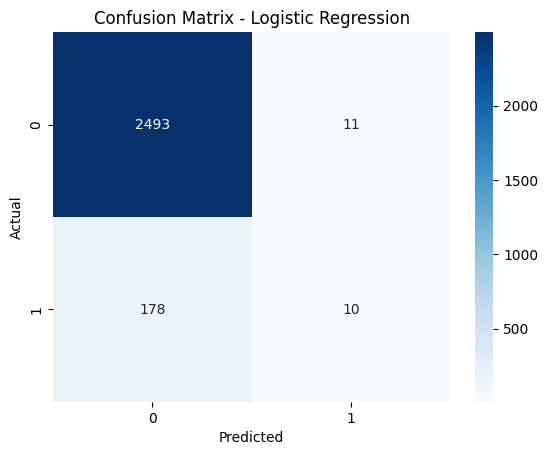


Accuracy: 0.9297919762258544
ROC AUC Score: 0.77


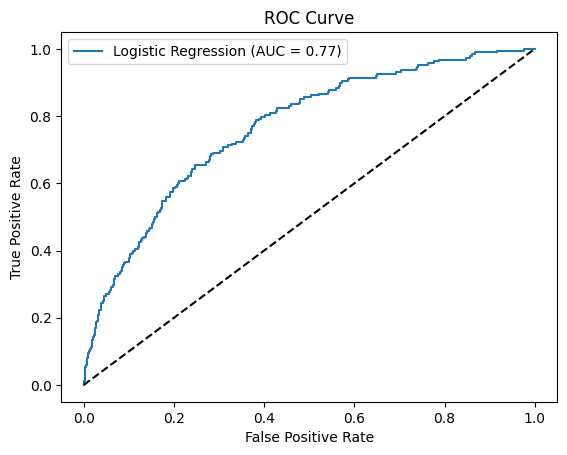

In [ ]:
# Use statsmodels to do OLS based on the training samples
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Train a logistic regression model
logit_model = sm.Logit(Y_train, X_train).fit()
print(logit_model.summary())

# Predict probabilities on test set
Y_pred_prob = logit_model.predict(X_test)

# Convert probabilities to binary predictions (threshold = 0.5 by default)
Y_pred = (Y_pred_prob >= 0.2).astype(int)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Visualize Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"\nAccuracy: {accuracy}")

# ROC AUC score (a good measure of model performance)
roc_auc = roc_auc_score(Y_test, Y_pred_prob)
print(f'ROC AUC Score: {roc_auc:.2f}')

# ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

###Step 10: Top 3 Predictors in Logistic Regression Model

  Feature  Coefficient  Abs_Coefficient
0      X6    -0.000798         0.000798
1      X8    -0.000612         0.000612
2     X15    -0.000327         0.000327


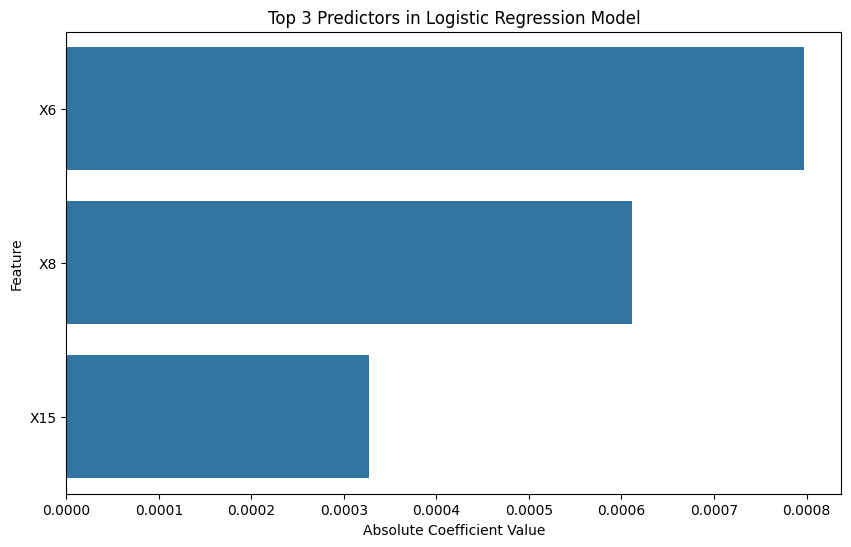

In [ ]:
# Get the feature names and corresponding coefficients
feature_names = X.columns
coefficients = logreg.coef_[0]

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate the absolute value of coefficients to rank them by importance
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

# Sort by absolute value of coefficients to get the top predictors
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Display the top 10 most important features
print(feature_importance.head(10))

# Visualize the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Coefficient', y='Feature', data=feature_importance.head(10))
plt.title('Top 3 Predictors in Logistic Regression Model')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

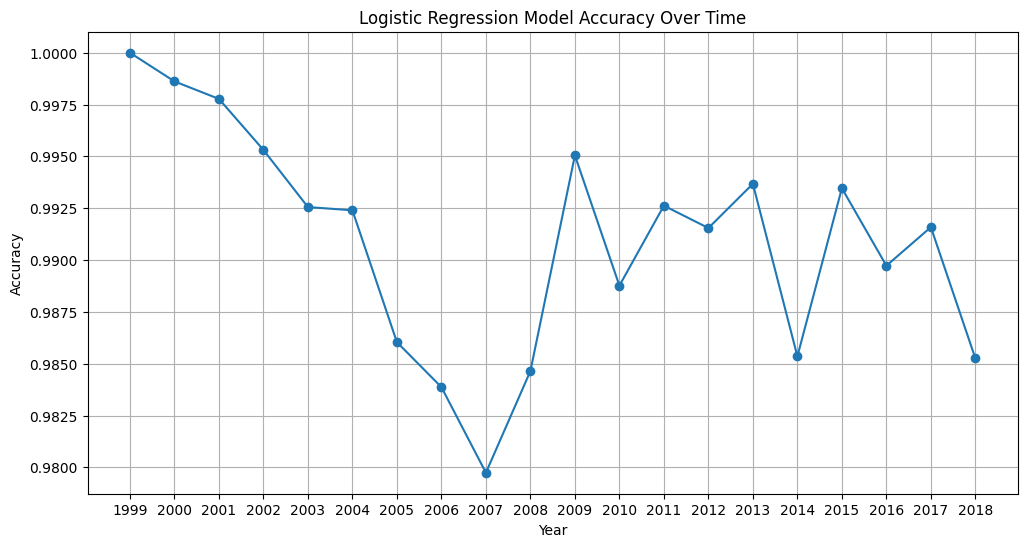

In [ ]:
# Define the selected variables
selected_variables = ['X6', 'X8', 'X15']

# Initialize an empty list to store accuracy results
year_accuracy = []

# Get the unique years
years = df_filtered['year'].unique()
years = np.sort(years)

# Loop through each year
for year in years:
    # Filter the dataset for the current year
    df_year = df_filtered[df_filtered['year'] == year]

    # Define features (X) and target (y)
    X = df_year[selected_variables]
    y = df_year['actual_status']

    # Split data into training and testing sets (80-20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train a Logistic Regression model
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy for the current year
    accuracy = accuracy_score(y_test, y_pred)
    year_accuracy.append(accuracy)

# Plot accuracy over time
plt.figure(figsize=(12, 6))  # Making the plot wider
plt.plot(years, year_accuracy, marker='o')
plt.title('Logistic Regression Model Accuracy Over Time')
plt.xlabel('Year')
plt.ylabel('Accuracy')
plt.grid(True)

# Ensure the x-axis shows whole years only
plt.xticks(np.arange(min(years), max(years) + 1, 1))  # Setting x-ticks to whole years

plt.show()

###Step 11: Use Random Forest to Build a Different Model

In [ ]:
X = df[['X6', 'X8', 'X15']]
Y = df['bankrupt']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest Model
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(Y_test, Y_pred_rf))

# Accuracy of Random Forest
rf_accuracy = accuracy_score(Y_test, Y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")


Random Forest Confusion Matrix:
[[2484   20]
 [ 171   17]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2504
           1       0.46      0.09      0.15       188

    accuracy                           0.93      2692
   macro avg       0.70      0.54      0.56      2692
weighted avg       0.90      0.93      0.91      2692

Random Forest Accuracy: 0.93


###Step 12: Compare Different Models

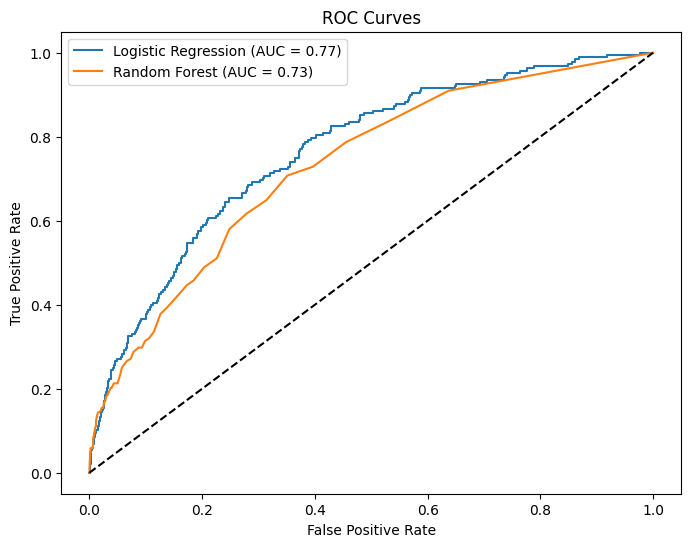

In [ ]:
# We compare different models. Logistic Regression Model performs better than Randowm Forest Model as it has higher AUC

# ROC Curve for Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(Y_test, rf_prob)
roc_auc_rf = roc_auc_score(Y_test, rf_prob)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()